# ML Mini Project

## Team members:

## Rekha Dhorigol, PES1UG24CS370

## Sai Manogna B V, PES1UG24CS399

### Section: G

### Title: Training a Playlist Curator Based on User Taste

# 1. Imports

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Saving model
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


# 2. Dataset

In [2]:
# Download Spotify dataset directly from Kaggle

!pip install -q kagglehub

import kagglehub
import os
import glob
import pandas as pd

# Download dataset from Kaggle
path = kagglehub.dataset_download("joebeachcapital/30000-spotify-songs")

print("Dataset downloaded to:")
print(path)

# Find CSV file
csv_files = glob.glob(path + "/**/*.csv", recursive=True)

print("\nCSV files found:")
for file in csv_files:
    print(file)

100%|██████████| 3.01M/3.01M [00:00<00:00, 4.65MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/joebeachcapital/30000-spotify-songs/versions/2

CSV files found:
/root/.cache/kagglehub/datasets/joebeachcapital/30000-spotify-songs/versions/2/spotify_songs.csv


In [3]:
# Load the Spotify dataset

csv_file = csv_files[0]

df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset loaded successfully!
Shape: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [4]:
# Basic information about the dataset

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (32833, 23)

Column names:
['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833

In [5]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
track_name          5
track_artist        5
track_album_name    5
dtype: int64


In [6]:
# Check our target variable: playlist_name

print("Number of unique playlists:",
      df["playlist_name"].nunique())

print("\nTop playlists:")
print(df["playlist_name"].value_counts().head(15))

Number of unique playlists: 449

Top playlists:
playlist_name
Indie Poptimism                                                                                  308
2020 Hits & 2019  Hits – Top Global Tracks 🔥🔥🔥                                                   247
Permanent Wave                                                                                   244
Hard Rock Workout                                                                                219
Ultimate Indie Presents... Best Indie Tracks of the 2010s                                        198
Fitness Workout Electro | House | Dance | Progressive House                                      195
Southern Hip Hop                                                                                 189
Charts 2020 🔥Top 2020🔥Hits 2020🔥Summer 2020🔥Pop 2020🔥Popular Music🔥Clean Pop 2020🔥Sing Alongs    189
Classic Rock 70s 80s 90s, Rock Classics - 70s Rock, 80s Rock, 90s Rock Rock  Classicos           182
Urban Contemporary           

# 3. EDA

In [7]:
# Playlist distribution

playlist_counts = df["playlist_name"].value_counts()

print("Total unique playlists:", len(playlist_counts))

print("\nPlaylist distribution:")
print(playlist_counts.describe())

print("\nTop 20 playlists:")
print(playlist_counts.head(20))

Total unique playlists: 449

Playlist distribution:
count    449.000000
mean      73.124722
std       36.151437
min        1.000000
25%       49.000000
50%       77.000000
75%       97.000000
max      308.000000
Name: count, dtype: float64

Top 20 playlists:
playlist_name
Indie Poptimism                                                                                  308
2020 Hits & 2019  Hits – Top Global Tracks 🔥🔥🔥                                                   247
Permanent Wave                                                                                   244
Hard Rock Workout                                                                                219
Ultimate Indie Presents... Best Indie Tracks of the 2010s                                        198
Fitness Workout Electro | House | Dance | Progressive House                                      195
Southern Hip Hop                                                                                 189
Charts 2020 🔥Top 202

In [8]:
# Check number of playlists based on minimum number of songs

for minimum in [10, 20, 50, 100, 200]:
    count = (playlist_counts >= minimum).sum()
    print(f"Playlists with at least {minimum} songs: {count}")

Playlists with at least 10 songs: 440
Playlists with at least 20 songs: 419
Playlists with at least 50 songs: 329
Playlists with at least 100 songs: 64
Playlists with at least 200 songs: 4


/tmp/ipykernel_571/4277098751.py:10: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


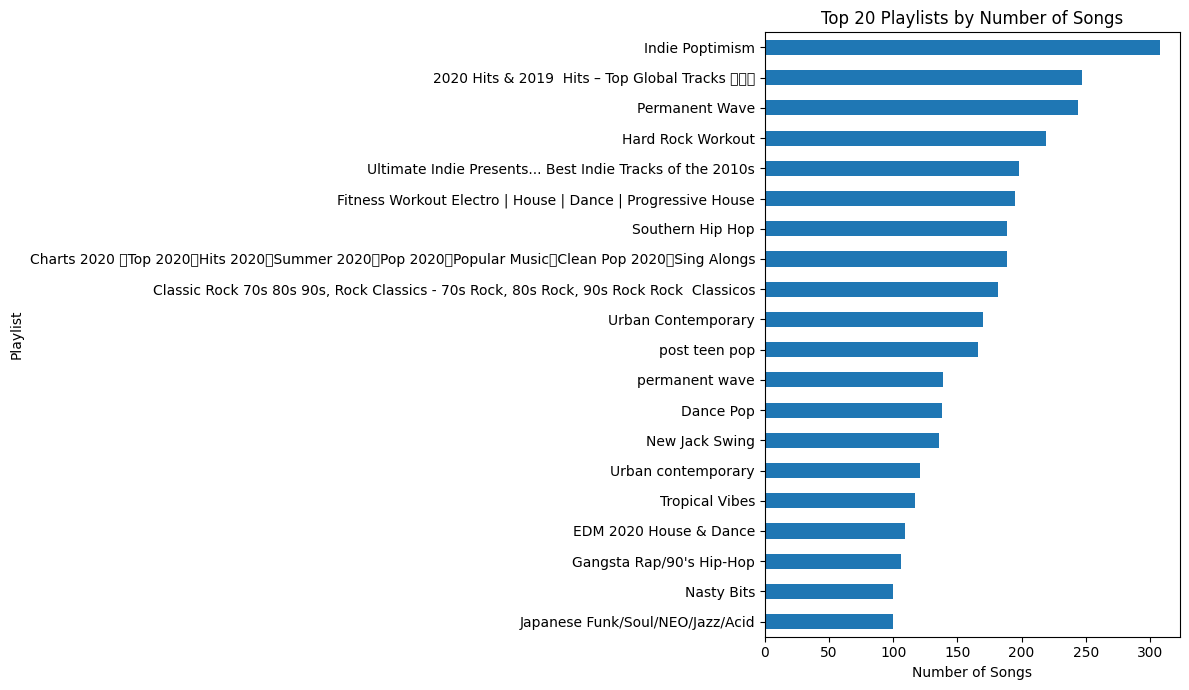

In [9]:
# Visualize the 20 most common playlists

plt.figure(figsize=(12, 7))

playlist_counts.head(20).sort_values().plot(kind="barh")

plt.title("Top 20 Playlists by Number of Songs")
plt.xlabel("Number of Songs")
plt.ylabel("Playlist")
plt.tight_layout()
plt.show()


# 4. Data Cleaning

In [10]:
# Clean playlist names for consistent class labels

import re

def clean_playlist_name(name):
    # Remove emojis and special symbols
    name = re.sub(r'[^\x00-\x7F]+', '', str(name))

    # Remove extra spaces
    name = re.sub(r'\s+', ' ', name).strip()

    # Make comparison case-insensitive
    return name.casefold()

# Create cleaned playlist labels
df["playlist_clean"] = df["playlist_name"].apply(clean_playlist_name)

# Count songs using cleaned playlist names
clean_playlist_counts = df["playlist_clean"].value_counts()

# Select 13 most represented DISTINCT playlists
selected_playlists = clean_playlist_counts.head(13).index.tolist()

print("Selected 13 distinct playlists:\n")

for i, playlist in enumerate(selected_playlists, 1):
    print(f"{i}. {playlist}")

print("\nNumber of selected playlists:", len(selected_playlists))

Selected 13 distinct playlists:

1. permanent wave
2. indie poptimism
3. urban contemporary
4. post teen pop
5. electropop
6. 2020 hits & 2019 hits top global tracks
7. hard rock workout
8. trap nation
9. ultimate indie presents... best indie tracks of the 2010s
10. neo-soul
11. fitness workout electro | house | dance | progressive house
12. southern hip hop
13. charts 2020 top 2020hits 2020summer 2020pop 2020popular musicclean pop 2020sing alongs

Number of selected playlists: 13


In [11]:
# Keep only the 13 selected playlists

df_selected = df[df["playlist_clean"].isin(selected_playlists)].copy()

print("Songs before balancing:", len(df_selected))

# Check songs available in each selected playlist
print("\nSongs per playlist:")
print(df_selected["playlist_clean"].value_counts())

Songs before balancing: 3690

Songs per playlist:
playlist_clean
permanent wave                                                                            491
indie poptimism                                                                           483
urban contemporary                                                                        457
post teen pop                                                                             317
electropop                                                                                308
2020 hits & 2019 hits top global tracks                                                   247
hard rock workout                                                                         219
trap nation                                                                               199
ultimate indie presents... best indie tracks of the 2010s                                 198
neo-soul                                                                                 

In [12]:
# Create a balanced dataset
# 80 songs from each of the 13 playlists

df_balanced = (
    df_selected
    .groupby("playlist_clean", group_keys=False)
    .sample(n=80, random_state=42)
    .reset_index(drop=True)
)

print("Final dataset shape:", df_balanced.shape)

print("\nSongs per playlist:")
print(df_balanced["playlist_clean"].value_counts())

print("\nNumber of unique playlists:",
      df_balanced["playlist_clean"].nunique())

Final dataset shape: (1040, 24)

Songs per playlist:
playlist_clean
2020 hits & 2019 hits top global tracks                                                   80
charts 2020 top 2020hits 2020summer 2020pop 2020popular musicclean pop 2020sing alongs    80
electropop                                                                                80
fitness workout electro | house | dance | progressive house                               80
hard rock workout                                                                         80
indie poptimism                                                                           80
neo-soul                                                                                  80
permanent wave                                                                            80
post teen pop                                                                             80
southern hip hop                                                                          80
tr

In [13]:
# Check for duplicate tracks

duplicate_track_ids = df_balanced["track_id"].duplicated().sum()

print("Duplicate track IDs:", duplicate_track_ids)

print("\nTotal rows:", len(df_balanced))
print("Unique track IDs:", df_balanced["track_id"].nunique())

Duplicate track IDs: 96

Total rows: 1040
Unique track IDs: 944


In [14]:
# Check how many tracks occur more than once

track_frequency = df_balanced["track_id"].value_counts()

print("Tracks appearing more than once:")
print((track_frequency > 1).sum())

print("\nMaximum occurrences of a single track:",
      track_frequency.max())

Tracks appearing more than once:
83

Maximum occurrences of a single track: 4


In [15]:
# Remove duplicate tracks

df_clean = df_balanced.drop_duplicates(
    subset="track_id",
    keep="first"
).reset_index(drop=True)

print("Dataset shape after removing duplicates:", df_clean.shape)

print("\nUnique tracks:",
      df_clean["track_id"].nunique())

print("\nSongs per playlist after removing duplicates:")
print(df_clean["playlist_clean"].value_counts())

Dataset shape after removing duplicates: (944, 24)

Unique tracks: 944

Songs per playlist after removing duplicates:
playlist_clean
electropop                                                                                80
hard rock workout                                                                         80
permanent wave                                                                            80
southern hip hop                                                                          80
neo-soul                                                                                  79
post teen pop                                                                             79
trap nation                                                                               79
indie poptimism                                                                           79
urban contemporary                                                                        77
2020 hits & 2019 hits top glob

In [16]:
# Check class sizes after removing duplicates

class_counts = df_clean["playlist_clean"].value_counts()

print("Songs per playlist:")
print(class_counts)

print("\nSmallest playlist size:", class_counts.min())
print("Largest playlist size:", class_counts.max())

Songs per playlist:
playlist_clean
electropop                                                                                80
hard rock workout                                                                         80
permanent wave                                                                            80
southern hip hop                                                                          80
neo-soul                                                                                  79
post teen pop                                                                             79
trap nation                                                                               79
indie poptimism                                                                           79
urban contemporary                                                                        77
2020 hits & 2019 hits top global tracks                                                   61
fitness workout electro | house | d

In [17]:
# Create final balanced dataset
# Use 52 unique songs from each playlist

df_final = (
    df_clean
    .groupby("playlist_clean", group_keys=False)
    .sample(n=52, random_state=42)
    .reset_index(drop=True)
)

print("Final dataset shape:", df_final.shape)

print("\nSongs per playlist:")
print(df_final["playlist_clean"].value_counts())

print("\nUnique tracks:", df_final["track_id"].nunique())

print("\nUnique playlists:", df_final["playlist_clean"].nunique())

Final dataset shape: (676, 24)

Songs per playlist:
playlist_clean
2020 hits & 2019 hits top global tracks                                                   52
charts 2020 top 2020hits 2020summer 2020pop 2020popular musicclean pop 2020sing alongs    52
electropop                                                                                52
fitness workout electro | house | dance | progressive house                               52
hard rock workout                                                                         52
indie poptimism                                                                           52
neo-soul                                                                                  52
permanent wave                                                                            52
post teen pop                                                                             52
southern hip hop                                                                          52
tra

# 5. Preprocessing

In [18]:
# Select the 10 audio features used in the paper

audio_features = [
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "liveness",
    "valence",
    "tempo"
]

print("Selected audio features:")
for i, feature in enumerate(audio_features, 1):
    print(f"{i}. {feature}")

Selected audio features:
1. danceability
2. energy
3. key
4. loudness
5. mode
6. speechiness
7. acousticness
8. liveness
9. valence
10. tempo


In [19]:
# Check for missing values in the selected features

print("Missing values in selected features:\n")
print(df_final[audio_features].isnull().sum())

print("\nTotal missing values:",
      df_final[audio_features].isnull().sum().sum())

Missing values in selected features:

danceability    0
energy          0
key             0
loudness        0
mode            0
speechiness     0
acousticness    0
liveness        0
valence         0
tempo           0
dtype: int64

Total missing values: 0


In [20]:
# Create input features (X) and target variable (y)

X = df_final[audio_features].copy()
y = df_final["playlist_clean"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\nNumber of target classes:", y.nunique())

X shape: (676, 10)
y shape: (676,)

X columns:
['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo']

Number of target classes: 13


In [21]:
# Display the first 5 feature rows and target values

print("First 5 X values:")
display(X.head())

print("\nFirst 5 y values:")
display(y.head())

First 5 X values:


,danceability,energy,key,loudness,mode,speechiness,acousticness,liveness,valence,tempo
0,0.784,0.645,10,-7.325,0,0.4020,0.00936,0.1170,0.590,109.978
1,0.760,0.479,2,-5.574,1,0.0466,0.55600,0.0703,0.913,89.911
2,0.655,0.722,0,-4.726,0,0.0480,0.55600,0.1330,0.298,90.099
3,0.602,0.377,11,-6.213,1,0.0446,0.73100,0.0808,0.518,73.877
4,0.599,0.887,4,-3.967,1,0.0984,0.01920,0.3000,0.881,170.918



First 5 y values:


,playlist_clean
0,2020 hits & 2019 hits top global tracks
1,2020 hits & 2019 hits top global tracks
2,2020 hits & 2019 hits top global tracks
3,2020 hits & 2019 hits top global tracks
4,2020 hits & 2019 hits top global tracks


# 6. Feature Engineering

In [22]:
# Feature Engineering

df_final["energy_dance_ratio"] = (
    df_final["energy"] / (df_final["danceability"] + 1e-6)
)

df_final["acoustic_energy_ratio"] = (
    df_final["acousticness"] / (df_final["energy"] + 1e-6)
)

df_final["tempo_energy"] = (
    df_final["tempo"] * df_final["energy"]
)

print("Engineered features created successfully!")

print("\nNew features:")
print([
    "energy_dance_ratio",
    "acoustic_energy_ratio",
    "tempo_energy"
])

Engineered features created successfully!

New features:
['energy_dance_ratio', 'acoustic_energy_ratio', 'tempo_energy']


In [23]:
# Check engineered features

engineered_features = [
    "energy_dance_ratio",
    "acoustic_energy_ratio",
    "tempo_energy"
]

display(df_final[engineered_features].head())

print("\nStatistics:")
display(df_final[engineered_features].describe())

,energy_dance_ratio,acoustic_energy_ratio,tempo_energy
0,0.822703,0.014512,70.935810
1,0.630262,1.160749,43.067369
2,1.102288,0.770082,65.051478
3,0.626245,1.938987,27.851629
4,1.480799,0.021646,151.604266



Statistics:


,energy_dance_ratio,acoustic_energy_ratio,tempo_energy
count,676.000000,676.000000,676.000000
mean,1.220707,0.467062,86.187795
std,0.610783,1.192261,34.295253
min,0.096604,0.000012,4.537088
25%,0.838295,0.010869,60.740557
50%,1.129774,0.080578,82.137599
75%,1.446137,0.412468,111.659352
max,7.623018,18.710572,194.198796


In [24]:
# Save processed dataset

df_final.to_csv(
    "playlist_curator_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")
print("Shape:", df_final.shape)

from google.colab import files
files.download('playlist_curator_processed.csv')

Processed dataset saved successfully!
Shape: (676, 27)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 7. Train/Test Split

In [25]:
# imports
import warnings
from functools import partial
from scipy.stats import loguniform
from sklearn.exceptions import ConvergenceWarning
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                     RandomizedSearchCV, cross_val_predict, validation_curve)
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.metrics import top_k_accuracy_score

warnings.filterwarnings("ignore", category=ConvergenceWarning)
RANDOM_STATE = 42

In [26]:
# Extra track-level features (paper lists release date etc. as "missing data")
df_final["release_year"] = pd.to_numeric(
    df_final["track_album_release_date"].astype(str).str[:4], errors="coerce")
df_final["release_year"] = df_final["release_year"].fillna(df_final["release_year"].median())

paper_features = list(audio_features)   # the 10 features used in the paper
extra_features = ["instrumentalness", "duration_ms", "track_popularity", "release_year"]

feature_sets = {
    "A_paper10":   paper_features,
    "B_paper+eng": paper_features + engineered_features,
    "C_all":       paper_features + engineered_features + extra_features,
}

# Labels
SHORT = {"2020 hits": "2020 Hits", "charts 2020": "Charts 2020",
         "fitness workout": "Fitness Electro", "ultimate indie": "Ultimate Indie"}
def short_name(s):
    for k, v in SHORT.items():
        if s.startswith(k):
            return v
    return s.title()

le = LabelEncoder()
y_all = le.fit_transform(df_final["playlist_clean"])
class_names = [short_name(c) for c in le.classes_]
n_classes = len(class_names)

In [27]:
# Stratified 80/20 split (same ratio as the paper)
# Test set is touched only for final reporting
idx_train, idx_test = train_test_split(
    np.arange(len(df_final)), test_size=0.2, stratify=y_all, random_state=RANDOM_STATE)
y_train, y_test = y_all[idx_train], y_all[idx_test]

def get_xy(fs_name):
    Xf = df_final[feature_sets[fs_name]]
    return Xf.iloc[idx_train], Xf.iloc[idx_test]

print("Train:", len(idx_train), "| Test:", len(idx_test), "| Classes:", n_classes)
print("Chance level accuracy: %.3f" % (1 / n_classes))
for k, v in feature_sets.items():
    print(f"{k}: {len(v)} features")

Train: 540 | Test: 136 | Classes: 13
Chance level accuracy: 0.077
A_paper10: 10 features
B_paper+eng: 13 features
C_all: 17 features


# 8. Baseline Models


**Note:** the paper's 2095 one-hot genre tags are not in this Kaggle dataset, so our baseline uses audio features only.

In [28]:
# Paper replication - Table 1 style (CV on the TRAINING split only)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_pipe(model, scale=True):
    steps = ([("scaler", StandardScaler())] if scale else []) + [("clf", model)]
    return Pipeline(steps)

def cv_score(model, X, y, scale=True, cv=cv5):
    s = cross_val_score(make_pipe(model, scale), X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    return s.mean(), s.std()

paper_models = {
    "Perceptron":  lambda: Perceptron(random_state=RANDOM_STATE),
    "Poly SVM":    lambda: SVC(kernel="poly", random_state=RANDOM_STATE),
    "Sigmoid SVM": lambda: SVC(kernel="sigmoid", random_state=RANDOM_STATE),
    "RBF SVM":     lambda: SVC(kernel="rbf", random_state=RANDOM_STATE),
    "NN (1 hidden layer, C neurons)": lambda: MLPClassifier(
        hidden_layer_sizes=(n_classes,), activation="logistic", max_iter=2000, random_state=RANDOM_STATE),
}

X_tr_A, _ = get_xy("A_paper10")
rows = []
for name, make in paper_models.items():
    ms, ss = cv_score(make(), X_tr_A, y_train, scale=True)
    mu, su = cv_score(make(), X_tr_A, y_train, scale=False)
    rows.append({"Model": name, "Scaled": f"{ms:.3f} (+/-{ss:.3f})", "Unscaled": f"{mu:.3f} (+/-{su:.3f})"})
baseline_table = pd.DataFrame(rows).set_index("Model")
display(baseline_table)


,Scaled,Unscaled
Model,,
Perceptron,0.169 (+/-0.043),0.098 (+/-0.017)
Poly SVM,0.230 (+/-0.048),0.144 (+/-0.025)
Sigmoid SVM,0.293 (+/-0.014),0.059 (+/-0.019)
RBF SVM,0.274 (+/-0.030),0.104 (+/-0.028)
"NN (1 hidden layer, C neurons)",0.311 (+/-0.025),0.207 (+/-0.044)


,A_paper10,B_paper+eng,C_all
RBF SVM,0.274,0.281,0.409
Logistic Regression,0.306,0.298,0.457
KNN (k=7),0.239,0.246,0.354
Random Forest,0.354,0.344,0.524
HistGradientBoosting,0.344,0.339,0.489


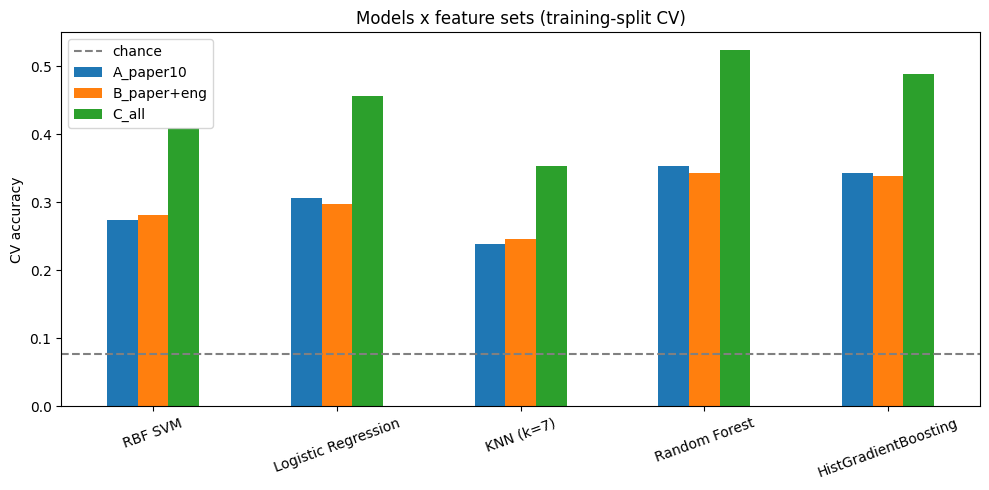

BEST_FS = C_all


In [29]:
# Our addition - more models x three feature sets (scaled, 5-fold CV on training split)
more_models = {
    "RBF SVM":              lambda: SVC(kernel="rbf", random_state=RANDOM_STATE),
    "Logistic Regression":  lambda: LogisticRegression(max_iter=3000),
    "KNN (k=7)":            lambda: KNeighborsClassifier(n_neighbors=7),
    "Random Forest":        lambda: RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1),
    "HistGradientBoosting": lambda: HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

res = {}
for fs in feature_sets:
    X_tr, _ = get_xy(fs)
    for name, make in more_models.items():
        res.setdefault(name, {})[fs] = cv_score(make(), X_tr, y_train)[0]
fs_table = pd.DataFrame(res).T.round(3)
display(fs_table)

fs_table.plot(kind="bar", figsize=(10, 5))
plt.axhline(1 / n_classes, color="gray", ls="--", label="chance")
plt.ylabel("CV accuracy"); plt.title("Models x feature sets (training-split CV)")
plt.xticks(rotation=20); plt.legend(); plt.tight_layout(); plt.show()

# Feature set used from here on = best on average across models
BEST_FS = fs_table.mean().idxmax()
print("BEST_FS =", BEST_FS)


# 9. Hyperparameter Tuning


In [30]:
# Hyperparameter search (TRAINING split only)
X_train, X_test = get_xy(BEST_FS)

scalers = [StandardScaler(),
           QuantileTransformer(n_quantiles=200, output_distribution="normal", random_state=RANDOM_STATE)]

searches = {
    "SVM": GridSearchCV(
        Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", random_state=RANDOM_STATE))]),
        {"scaler": scalers,
         "clf__C": [0.1, 0.3, 1, 3, 10, 30, 100],
         "clf__gamma": ["scale", 0.003, 0.01, 0.03, 0.1, 0.3]},
        cv=cv5, scoring="accuracy", n_jobs=-1),

    "Random Forest": RandomizedSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
        {"n_estimators": [200, 400, 600],
         "max_depth": [None, 5, 8, 12, 20],
         "min_samples_leaf": [1, 2, 4],
         "max_features": ["sqrt", "log2", 0.5]},
        n_iter=25, cv=cv5, scoring="accuracy", n_jobs=-1, random_state=RANDOM_STATE),

    "MLP": RandomizedSearchCV(
        Pipeline([("scaler", StandardScaler()),
                  ("clf", MLPClassifier(max_iter=2000, random_state=RANDOM_STATE))]),
        {"scaler": scalers,
         "clf__hidden_layer_sizes": [(n_classes,), (2 * n_classes,), (64,), (64, 32), (128, 64)],
         "clf__activation": ["logistic", "relu", "tanh"],
         "clf__alpha": loguniform(1e-5, 1e-1),
         "clf__learning_rate_init": [1e-3, 3e-3, 1e-2]},
        n_iter=30, cv=cv5, scoring="accuracy", n_jobs=-1, random_state=RANDOM_STATE),

    "HistGB": RandomizedSearchCV(
        HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        {"learning_rate": [0.03, 0.05, 0.1],
         "max_depth": [None, 3, 5],
         "max_leaf_nodes": [8, 15, 31],
         "l2_regularization": [0, 0.1, 1, 10],
         "min_samples_leaf": [10, 20, 40]},
        n_iter=20, cv=cv5, scoring="accuracy", n_jobs=-1, random_state=RANDOM_STATE),
}

best_models, rows = {}, []
for name, search in searches.items():
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    rows.append({"Model": name, "Best CV acc": round(search.best_score_, 3), "Best params": search.best_params_})
    print(f"{name}: {search.best_score_:.3f}")
tuning_table = pd.DataFrame(rows).set_index("Model")
pd.set_option("display.max_colwidth", 200)
display(tuning_table)


SVM: 0.469
Random Forest: 0.544
MLP: 0.456
HistGB: 0.528


,Best CV acc,Best params
Model,,
SVM,0.469,"{'clf__C': 30, 'clf__gamma': 0.003, 'scaler': QuantileTransformer(n_quantiles=200, output_distribution='normal', random_state=42)}"
Random Forest,0.544,"{'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 12}"
MLP,0.456,"{'clf__activation': 'logistic', 'clf__alpha': 1.8205657658407255e-05, 'clf__hidden_layer_sizes': (64, 32), 'clf__learning_rate_init': 0.001, 'scaler': QuantileTransformer(n_quantiles=200, output_d..."
HistGB,0.528,"{'min_samples_leaf': 40, 'max_leaf_nodes': 15, 'max_depth': None, 'learning_rate': 0.03, 'l2_regularization': 0}"


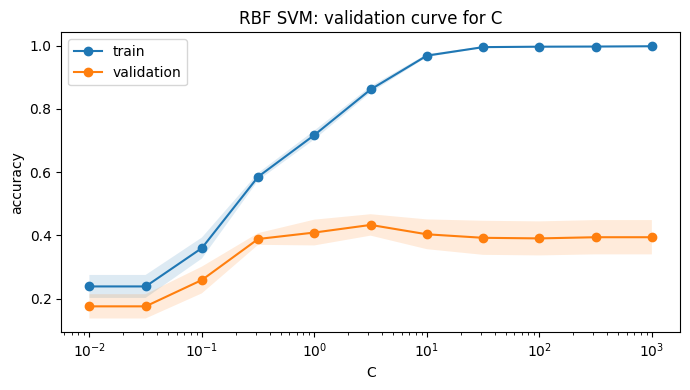

Best C on validation curve: 3.1622776601683795


In [31]:
# Parameter tuning visual - effect of SVM penalty C (validation curve)
C_range = np.logspace(-2, 3, 11)
svm_probe = Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", gamma="scale"))])
tr_sc, va_sc = validation_curve(svm_probe, X_train, y_train, param_name="clf__C",
                                param_range=C_range, cv=cv5, scoring="accuracy", n_jobs=-1)

plt.figure(figsize=(7, 4))
for sc, lab in [(tr_sc, "train"), (va_sc, "validation")]:
    plt.semilogx(C_range, sc.mean(1), marker="o", label=lab)
    plt.fill_between(C_range, sc.mean(1) - sc.std(1), sc.mean(1) + sc.std(1), alpha=0.15)
plt.xlabel("C"); plt.ylabel("accuracy"); plt.title("RBF SVM: validation curve for C")
plt.legend(); plt.tight_layout(); plt.show()
print("Best C on validation curve:", C_range[va_sc.mean(1).argmax()])


# 10. Cross-Validation


,mean,std
Random Forest (tuned),0.527,0.046
HistGB (tuned),0.523,0.034
SVM (tuned),0.470,0.051
MLP (tuned),0.459,0.045
Baseline NN (1 hidden layer),0.310,0.030
"Baseline RBF SVM (10 audio, default)",0.294,0.033


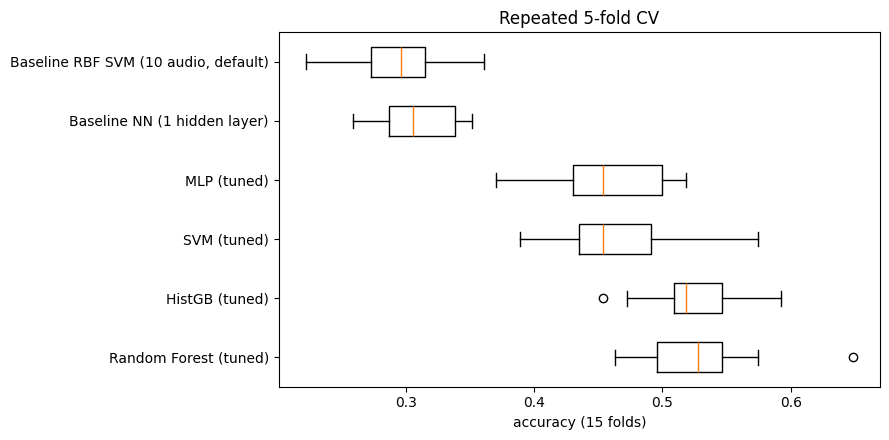

In [32]:
# Repeated cross-validation
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

candidates_cv = {
    "Baseline RBF SVM (10 audio, default)": (make_pipe(SVC(kernel="rbf", random_state=RANDOM_STATE)), "A_paper10"),
    "Baseline NN (1 hidden layer)": (make_pipe(MLPClassifier(
        hidden_layer_sizes=(n_classes,), activation="logistic", max_iter=2000,
        random_state=RANDOM_STATE)), "A_paper10"),
}
for k, v in best_models.items():
    candidates_cv[f"{k} (tuned)"] = (v, BEST_FS)

cv_scores = {}
for name, (est, fs) in candidates_cv.items():
    Xtr, _ = get_xy(fs)
    cv_scores[name] = cross_val_score(clone(est), Xtr, y_train, cv=rcv, scoring="accuracy", n_jobs=-1)

cv_summary = pd.DataFrame({k: {"mean": v.mean(), "std": v.std()} for k, v in cv_scores.items()}).T
cv_summary = cv_summary.sort_values("mean", ascending=False).round(3)
display(cv_summary)

plt.figure(figsize=(9, 4.5))
order = cv_summary.index.tolist()
plt.boxplot([cv_scores[n] for n in order], vert=False)
plt.yticks(range(1, len(order) + 1), order)
plt.xlabel("accuracy (15 folds)"); plt.title("Repeated 5-fold CV"); plt.tight_layout(); plt.show()


# 11. Feature Selection


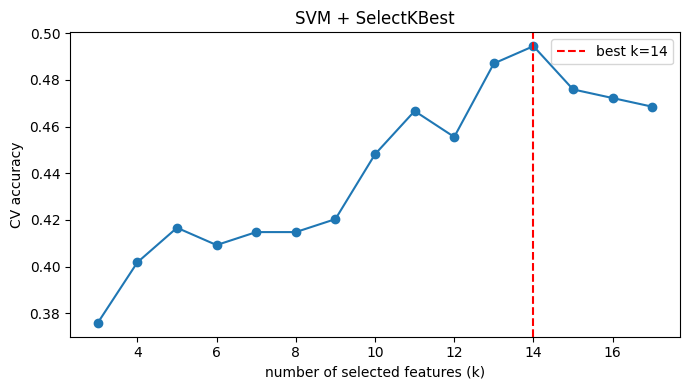

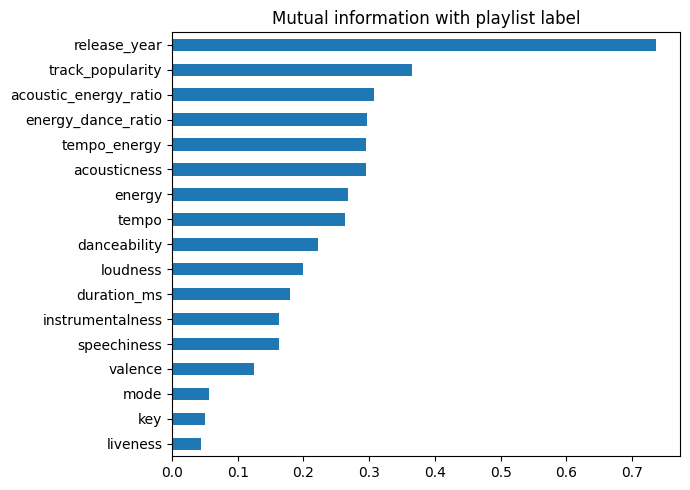

BEST_K = 14 | CV acc = 0.494
Top features: ['release_year', 'track_popularity', 'acoustic_energy_ratio', 'energy_dance_ratio', 'tempo_energy', 'acousticness', 'energy', 'tempo', 'danceability', 'loudness', 'duration_ms', 'instrumentalness', 'speechiness', 'valence']


In [33]:
# Feature selection with mutual information (inside the pipeline)
svm_best = best_models["SVM"]
mi = partial(mutual_info_classif, random_state=RANDOM_STATE)

def svm_with_k(k):
    return Pipeline([("scaler", clone(svm_best.named_steps["scaler"])),
                     ("select", SelectKBest(mi, k=k)),
                     ("clf", clone(svm_best.named_steps["clf"]))])

n_feat = X_train.shape[1]
ks = list(range(3, n_feat + 1))
k_scores = [cross_val_score(svm_with_k(k), X_train, y_train, cv=cv5, n_jobs=-1).mean() for k in ks]
BEST_K = ks[int(np.argmax(k_scores))]

plt.figure(figsize=(7, 4))
plt.plot(ks, k_scores, marker="o"); plt.axvline(BEST_K, color="red", ls="--", label=f"best k={BEST_K}")
plt.xlabel("number of selected features (k)"); plt.ylabel("CV accuracy")
plt.title("SVM + SelectKBest"); plt.legend(); plt.tight_layout(); plt.show()

mi_scores = pd.Series(mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE),
                      index=X_train.columns).sort_values()
mi_scores.plot(kind="barh", figsize=(7, 5), title="Mutual information with playlist label")
plt.tight_layout(); plt.show()

selected_svm = svm_with_k(BEST_K)
print("BEST_K =", BEST_K, "| CV acc = %.3f" % max(k_scores))
print("Top features:", mi_scores.index[::-1][:BEST_K].tolist())


# 12. Model Comparison


,Features,CV acc (train),Test acc,Test macro-F1,Test top-3 acc
Model,,,,,
Random Forest (tuned),C_all,0.527,0.551,0.548,0.779
HistGB (tuned),C_all,0.523,0.515,0.508,0.801
Soft-voting ensemble (tuned),C_all,0.519,0.471,0.466,0.794
SVM (tuned) + SelectKBest,C_all,0.495,0.515,0.511,0.824
SVM (tuned),C_all,0.470,0.426,0.426,0.794
MLP (tuned),C_all,0.459,0.434,0.428,0.706
Baseline NN (1 hidden layer),A_paper10,0.310,0.301,0.282,0.574
"Baseline RBF SVM (10 audio, default)",A_paper10,0.294,0.301,0.286,0.632
Perceptron (paper baseline),A_paper10,0.194,0.154,0.138,NaN


FINAL_NAME = Random Forest (tuned)


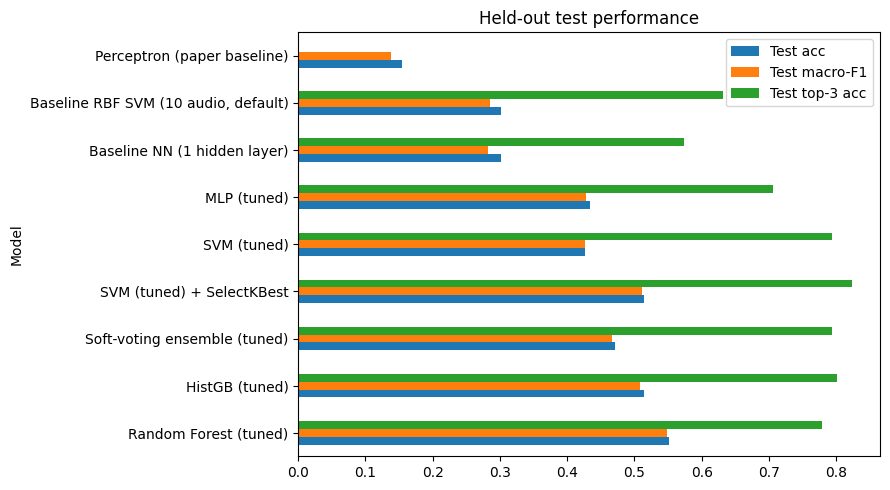

In [34]:
# Model comparison
def with_proba(est):
    est = clone(est)
    if "clf__probability" in est.get_params():
        est.set_params(clf__probability=True)
    return est

cands = dict(candidates_cv)
cands["Perceptron (paper baseline)"] = (make_pipe(Perceptron(random_state=RANDOM_STATE)), "A_paper10")
cands["SVM (tuned) + SelectKBest"] = (selected_svm, BEST_FS)
cands["Soft-voting ensemble (tuned)"] = (VotingClassifier(
    [(k.lower().replace(" ", "_"), with_proba(v)) for k, v in best_models.items()],
    voting="soft", n_jobs=1), BEST_FS)

rows, fitted = [], {}
for name, (est, fs) in cands.items():
    Xtr, Xte = get_xy(fs)
    if name not in cv_scores:
        cv_scores[name] = cross_val_score(with_proba(est), Xtr, y_train, cv=rcv, scoring="accuracy", n_jobs=-1)
    m = with_proba(est).fit(Xtr, y_train)
    fitted[name] = m
    pred = m.predict(Xte)
    top3 = (top_k_accuracy_score(y_test, m.predict_proba(Xte), k=3, labels=np.arange(n_classes))
            if hasattr(m, "predict_proba") else np.nan)
    rows.append({"Model": name, "Features": fs,
                 "CV acc (train)": cv_scores[name].mean(),
                 "Test acc": accuracy_score(y_test, pred),
                 "Test macro-F1": f1_score(y_test, pred, average="macro"),
                 "Test top-3 acc": top3})
comparison = pd.DataFrame(rows).set_index("Model").sort_values("CV acc (train)", ascending=False).round(3)
display(comparison)

# Final model: best CV score among models that give probabilities
FINAL_NAME = comparison["CV acc (train)"][comparison["Test top-3 acc"].notna()].idxmax()
print("FINAL_NAME =", FINAL_NAME)

comparison[["Test acc", "Test macro-F1", "Test top-3 acc"]].plot(kind="barh", figsize=(9, 5))
plt.title("Held-out test performance"); plt.tight_layout(); plt.show()


,n_features,CV acc,CV std,Test acc
Feature set,,,,
A: paper 10 audio features,10,0.358,0.030,0.324
B: A + engineered ratios,13,0.349,0.030,0.279
C minus release_year,16,0.434,0.028,0.412
C minus release_year & popularity,15,0.377,0.033,0.368
C: all 17 (final model),17,0.527,0.046,0.551


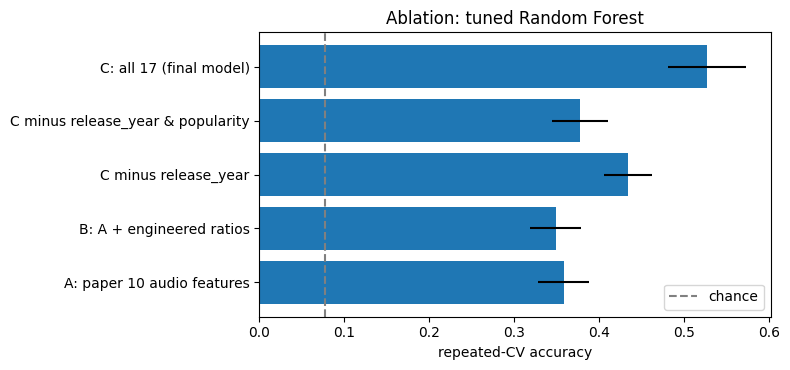

In [35]:
# Ablation - how much do the metadata features (especially release_year) matter?
# Same tuned Random Forest, different feature subsets, repeated CV on the training split.
rf_best = best_models["Random Forest"]
c_all = feature_sets["C_all"]
ablation_sets = {
    "A: paper 10 audio features":        paper_features,
    "B: A + engineered ratios":          paper_features + engineered_features,
    "C minus release_year":              [f for f in c_all if f != "release_year"],
    "C minus release_year & popularity": [f for f in c_all if f not in ("release_year", "track_popularity")],
    "C: all 17 (final model)":           c_all,
}

rows = []
for name, cols in ablation_sets.items():
    Xtr, Xte = df_final[cols].iloc[idx_train], df_final[cols].iloc[idx_test]
    sc = cross_val_score(clone(rf_best), Xtr, y_train, cv=rcv, scoring="accuracy", n_jobs=-1)
    m = clone(rf_best).fit(Xtr, y_train)
    rows.append({"Feature set": name, "n_features": len(cols),
                 "CV acc": sc.mean(), "CV std": sc.std(),
                 "Test acc": accuracy_score(y_test, m.predict(Xte))})
ablation = pd.DataFrame(rows).set_index("Feature set").round(3)
display(ablation)

plt.figure(figsize=(8, 3.8))
plt.barh(ablation.index, ablation["CV acc"], xerr=ablation["CV std"])
plt.axvline(1 / n_classes, color="gray", ls="--", label="chance")
plt.xlabel("repeated-CV accuracy"); plt.title("Ablation: tuned Random Forest")
plt.legend(); plt.tight_layout(); plt.show()


Segmentation experiment (idea from the paper): accuracy vs number of playlists

The paper observed that accuracy rises when a user only has a few playlists (it averaged random 5-playlist subsets).

We repeat this for several k with our tuned models: CV on random k-playlist subsets of the training split.

,Playlists (k),Model,Mean CV acc,Std across subsets,Chance (1/k)
0,2,SVM (tuned),0.828,0.108,0.500
1,2,Random Forest (tuned),0.863,0.091,0.500
2,3,SVM (tuned),0.750,0.123,0.333
3,3,Random Forest (tuned),0.816,0.106,0.333
4,5,SVM (tuned),0.653,0.092,0.200
5,5,Random Forest (tuned),0.725,0.092,0.200
6,8,SVM (tuned),0.568,0.067,0.125
7,8,Random Forest (tuned),0.621,0.067,0.125
8,13,SVM (tuned),0.469,0.000,0.077
9,13,Random Forest (tuned),0.544,0.000,0.077


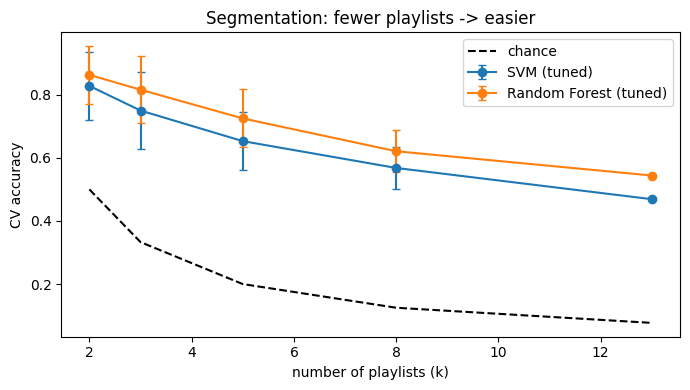

In [36]:
# Segmentation experiment
seg_rng = np.random.default_rng(RANDOM_STATE)
seg_models = {"SVM (tuned)": best_models["SVM"], "Random Forest (tuned)": best_models["Random Forest"]}
ks_seg = [2, 3, 5, 8, n_classes]
N_TRIALS = 20    # random playlist subsets per k
seg_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for k in ks_seg:
    subsets = [seg_rng.choice(n_classes, size=k, replace=False)
               for _ in range(1 if k == n_classes else N_TRIALS)]
    for name, est in seg_models.items():
        accs = []
        for sub in subsets:
            keep = np.where(np.isin(y_train, sub))[0]
            accs.append(cross_val_score(clone(est), X_train.iloc[keep], y_train[keep],
                                        cv=seg_cv, scoring="accuracy", n_jobs=-1).mean())
        rows.append({"Playlists (k)": k, "Model": name, "Mean CV acc": np.mean(accs),
                     "Std across subsets": np.std(accs), "Chance (1/k)": 1 / k})
seg_table = pd.DataFrame(rows).round(3)
display(seg_table)

plt.figure(figsize=(7, 4))
for name in seg_models:
    d = seg_table[seg_table["Model"] == name]
    plt.errorbar(d["Playlists (k)"], d["Mean CV acc"], yerr=d["Std across subsets"], marker="o", capsize=3, label=name)
d = seg_table[seg_table["Model"] == "SVM (tuned)"]
plt.plot(d["Playlists (k)"], d["Chance (1/k)"], "k--", label="chance")
plt.xlabel("number of playlists (k)"); plt.ylabel("CV accuracy")
plt.title("Segmentation: fewer playlists -> easier"); plt.legend(); plt.tight_layout(); plt.show()


# 13. Error Analysis


                    precision    recall  f1-score   support

         2020 Hits       0.50      0.50      0.50        10
       Charts 2020       0.31      0.40      0.35        10
        Electropop       1.00      0.60      0.75        10
   Fitness Electro       0.67      0.91      0.77        11
 Hard Rock Workout       0.75      0.82      0.78        11
   Indie Poptimism       0.17      0.10      0.12        10
          Neo-Soul       0.20      0.18      0.19        11
    Permanent Wave       1.00      0.82      0.90        11
     Post Teen Pop       0.46      0.60      0.52        10
  Southern Hip Hop       1.00      0.90      0.95        10
       Trap Nation       0.60      0.27      0.38        11
    Ultimate Indie       0.50      0.50      0.50        10
Urban Contemporary       0.33      0.55      0.41        11

          accuracy                           0.55       136
         macro avg       0.58      0.55      0.55       136
      weighted avg       0.58      0.5

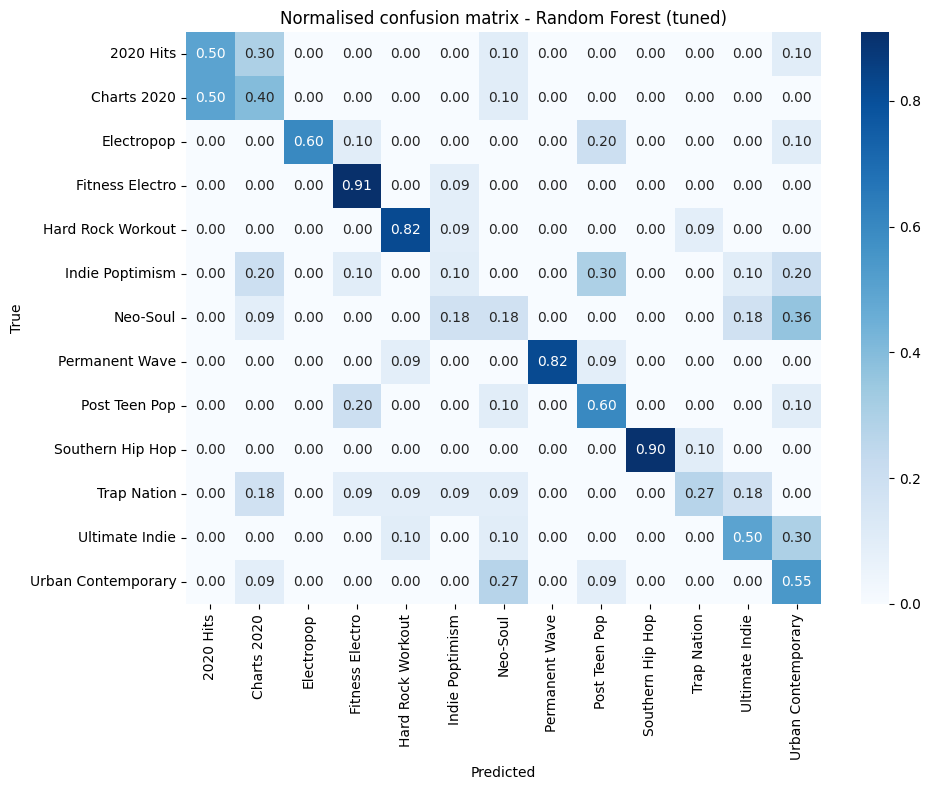

Most confused pairs (true -> predicted : count)
  Charts 2020 -> 2020 Hits : 5
  Neo-Soul -> Urban Contemporary : 4
  2020 Hits -> Charts 2020 : 3
  Indie Poptimism -> Post Teen Pop : 3
  Ultimate Indie -> Urban Contemporary : 3
  Urban Contemporary -> Neo-Soul : 3
  Electropop -> Post Teen Pop : 2
  Indie Poptimism -> Charts 2020 : 2


In [37]:
# Error analysis of the final model
final_fs = cands[FINAL_NAME][1]
_, X_te = get_xy(final_fs)
final_est = fitted[FINAL_NAME]
y_pred = final_est.predict(X_te)

print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

cm_raw = confusion_matrix(y_test, y_pred, labels=np.arange(n_classes))
cm = cm_raw / cm_raw.sum(1, keepdims=True)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Normalised confusion matrix - {FINAL_NAME}")
plt.tight_layout(); plt.show()

off = cm_raw.copy(); np.fill_diagonal(off, 0)
pairs = [(class_names[i], class_names[j], off[i, j]) for i in range(n_classes) for j in range(n_classes) if off[i, j] > 0]
pairs = sorted(pairs, key=lambda t: -t[2])[:8]
print("Most confused pairs (true -> predicted : count)")
for a, b, c in pairs:
    print(f"  {a} -> {b} : {c}")


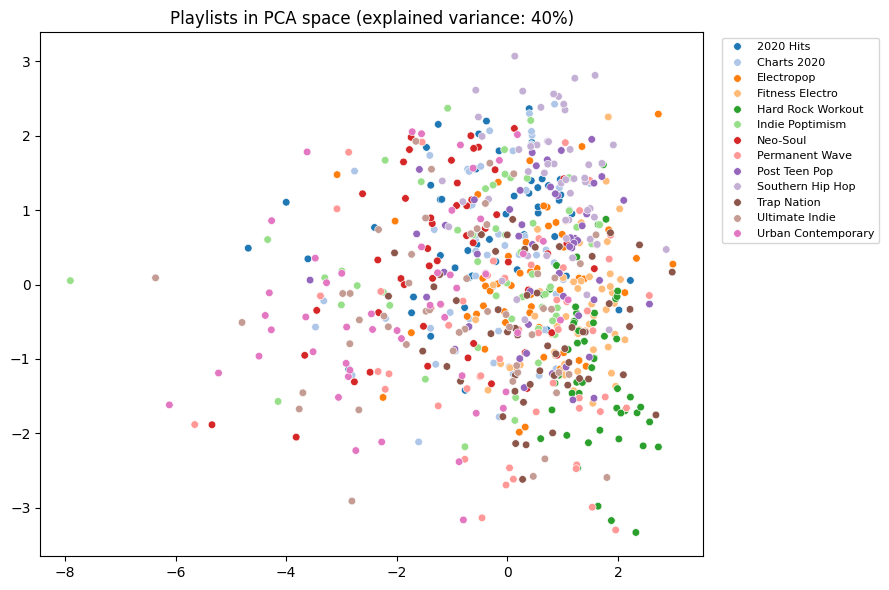

In [38]:
# Why is it hard? 2-D PCA of the paper's 10 audio features (cf. paper Fig. 3)
Z = StandardScaler().fit_transform(df_final[paper_features])
P = PCA(n_components=2, random_state=RANDOM_STATE).fit(Z)
Z2 = P.transform(Z)
plt.figure(figsize=(9, 6))
sns.scatterplot(x=Z2[:, 0], y=Z2[:, 1], hue=[short_name(c) for c in df_final["playlist_clean"]],
                palette="tab20", s=30)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.title("Playlists in PCA space (explained variance: %.0f%%)" % (100 * P.explained_variance_ratio_.sum()))
plt.tight_layout(); plt.show()


# 14. Explainability


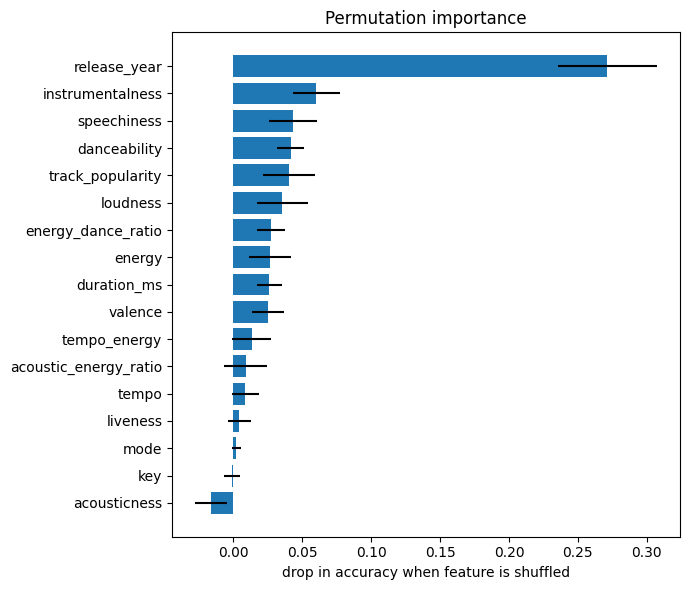

,mean,std
release_year,0.2713,0.0360
instrumentalness,0.0603,0.0169
speechiness,0.0434,0.0177
danceability,0.0415,0.0099
track_popularity,0.0404,0.0185
loudness,0.0357,0.0182
energy_dance_ratio,0.0276,0.0101
energy,0.0268,0.0153


In [39]:
# Permutation importance on the held-out test set (final model)
pi = permutation_importance(final_est, X_te, y_test, n_repeats=20, random_state=RANDOM_STATE,
                            scoring="accuracy", n_jobs=-1)
imp = pd.DataFrame({"mean": pi.importances_mean, "std": pi.importances_std},
                   index=X_te.columns).sort_values("mean")
plt.figure(figsize=(7, 6))
plt.barh(imp.index, imp["mean"], xerr=imp["std"])
plt.xlabel("drop in accuracy when feature is shuffled"); plt.title("Permutation importance")
plt.tight_layout(); plt.show()
display(imp.sort_values("mean", ascending=False).round(4).head(8))


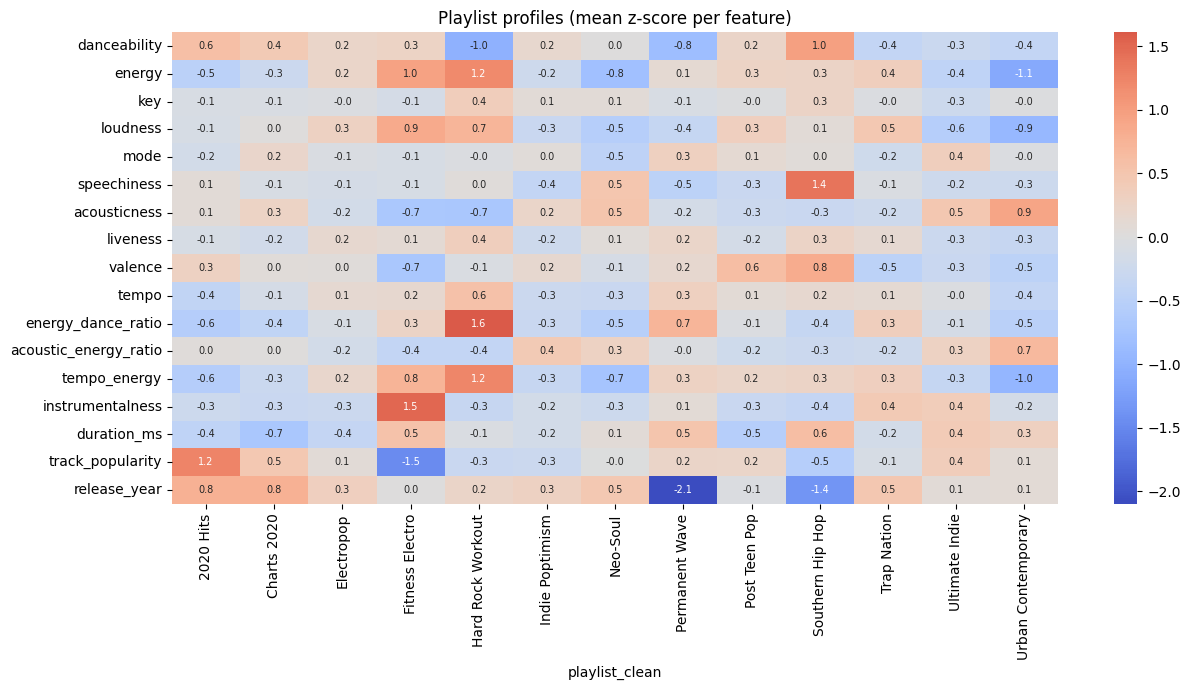

In [40]:
# What defines each playlist? Mean z-score of each feature per playlist
feats = feature_sets["C_all"]
zdf = (df_final[feats] - df_final[feats].mean()) / df_final[feats].std()
profile = zdf.groupby(df_final["playlist_clean"].map(short_name)).mean().T
plt.figure(figsize=(13, 7))
sns.heatmap(profile, cmap="coolwarm", center=0, annot=True, fmt=".1f", annot_kws={"size": 7})
plt.title("Playlist profiles (mean z-score per feature)"); plt.tight_layout(); plt.show()


# 15. Final Model


**Abstain threshold** ("parameter tuning" of the decision rule).

The paper's problem statement asks to either assign a song to a playlist or suggest a new playlist.

We implement this: if the model's top probability is below a threshold, it recommends creating a new playlist. The threshold is tuned on out-of-fold training predictions (coverage vs accuracy trade-off), then the model is refit on all data and saved.

,threshold,coverage,acc_on_accepted
0,0.00,1.000,0.544
1,0.05,1.000,0.544
2,0.10,1.000,0.544
3,0.15,0.996,0.545
4,0.20,0.941,0.551
5,0.25,0.794,0.611
6,0.30,0.644,0.655
7,0.35,0.522,0.702
8,0.40,0.428,0.736
9,0.45,0.331,0.777


Overall OOF accuracy: 0.544 | chosen ABSTAIN_THRESHOLD = 0.30


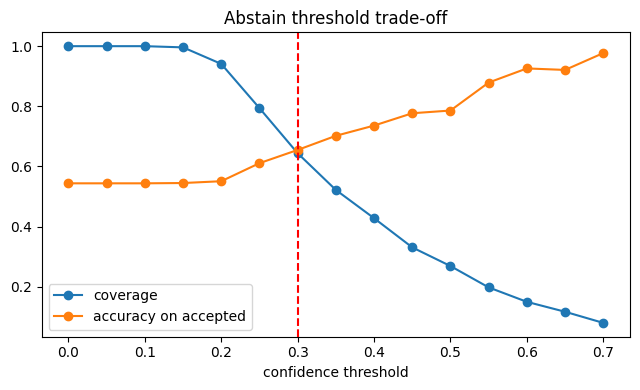

Test: coverage 0.71 | accuracy on accepted 0.635 | accuracy on all 0.551


In [41]:
# Tune the abstain threshold on out-of-fold probabilities (training split only)
Xtr_f, _ = get_xy(final_fs)
oof_proba = cross_val_predict(with_proba(cands[FINAL_NAME][0]), Xtr_f, y_train,
                              cv=cv5, method="predict_proba", n_jobs=-1)
oof_pred, oof_conf = oof_proba.argmax(1), oof_proba.max(1)
overall = (oof_pred == y_train).mean()

rows = []
for t in np.arange(0.0, 0.75, 0.05):
    keep = oof_conf >= t
    rows.append({"threshold": round(float(t), 2), "coverage": keep.mean(),
                 "acc_on_accepted": (oof_pred[keep] == y_train[keep]).mean() if keep.any() else np.nan})
thr_table = pd.DataFrame(rows).round(3)
display(thr_table)

ok = thr_table[(thr_table["coverage"] >= 0.6) & (thr_table["acc_on_accepted"] >= overall + 0.05)]
ABSTAIN_THRESHOLD = float(ok["threshold"].max()) if len(ok) else 0.30
print("Overall OOF accuracy: %.3f | chosen ABSTAIN_THRESHOLD = %.2f" % (overall, ABSTAIN_THRESHOLD))

plt.figure(figsize=(6.5, 4))
plt.plot(thr_table["threshold"], thr_table["coverage"], marker="o", label="coverage")
plt.plot(thr_table["threshold"], thr_table["acc_on_accepted"], marker="o", label="accuracy on accepted")
plt.axvline(ABSTAIN_THRESHOLD, color="red", ls="--"); plt.xlabel("confidence threshold")
plt.legend(); plt.title("Abstain threshold trade-off"); plt.tight_layout(); plt.show()

# Check on the untouched test set (model fitted on train only)
conf_te = final_est.predict_proba(X_te).max(1)
keep_te = conf_te >= ABSTAIN_THRESHOLD
print("Test: coverage %.2f | accuracy on accepted %.3f | accuracy on all %.3f" % (
    keep_te.mean(), (final_est.predict(X_te)[keep_te] == y_test[keep_te]).mean(), accuracy_score(y_test, final_est.predict(X_te))))


In [42]:
# Refit the final model on ALL labelled data and save it
X_all_final = df_final[feature_sets[final_fs]]
final_model = with_proba(cands[FINAL_NAME][0]).fit(X_all_final, y_all)

joblib.dump({"model": final_model, "label_encoder": le, "features": feature_sets[final_fs],
             "class_names": class_names, "threshold": ABSTAIN_THRESHOLD, "final_name": FINAL_NAME},
            "playlist_curator_final.joblib")
print("Saved playlist_curator_final.joblib  ->", FINAL_NAME, "|", final_fs)

files.download('playlist_curator_final.joblib')


Saved playlist_curator_final.joblib  -> Random Forest (tuned) | C_all


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 16. Playlist Prediction Demo

In [43]:
# Playlist prediction demo
artifact = joblib.load("playlist_curator_final.joblib")

def build_features(raw):
    d = pd.DataFrame(raw).copy()
    d["energy_dance_ratio"] = d["energy"] / (d["danceability"] + 1e-6)
    d["acoustic_energy_ratio"] = d["acousticness"] / (d["energy"] + 1e-6)
    d["tempo_energy"] = d["tempo"] * d["energy"]
    if "release_year" not in d and "track_album_release_date" in d:
        d["release_year"] = pd.to_numeric(d["track_album_release_date"].astype(str).str[:4], errors="coerce")
    for c in artifact["features"]:    # anything not supplied -> training median
        if c not in d:
            d[c] = df_final[c].median()
        d[c] = d[c].fillna(df_final[c].median())
    return d[artifact["features"]]

def recommend_playlist(raw, top_n=3):
    proba = artifact["model"].predict_proba(build_features(raw))
    out = []
    for p in proba:
        top = p.argsort()[::-1][:top_n]
        out.append({"suggestions": [(artifact["class_names"][i], round(float(p[i]), 3)) for i in top],
                    "new_playlist_suggested": bool(p.max() < artifact["threshold"])})
    return out

# i) Manual input: typed in a song's audio features
my_song = {"danceability": 0.78, "energy": 0.55, "key": 5, "loudness": -7.0, "mode": 0,
           "speechiness": 0.30, "acousticness": 0.10, "liveness": 0.12, "valence": 0.45, "tempo": 140.0}
print("Manual song ->", recommend_playlist([my_song])[0])

# ii) Out-of-set validation: songs from the 13 playlists that were NEVER in df_final
df_unseen = (df[df["playlist_clean"].isin(selected_playlists) & ~df["track_id"].isin(df_final["track_id"])]
             .drop_duplicates("track_id"))
y_unseen = le.transform(df_unseen["playlist_clean"])
P_unseen = artifact["model"].predict_proba(build_features(df_unseen))
print(f"\nUnseen songs: {len(df_unseen)}")
print("Accuracy: %.3f | macro-F1: %.3f | top-3: %.3f" % (
    accuracy_score(y_unseen, P_unseen.argmax(1)),
    f1_score(y_unseen, P_unseen.argmax(1), average="macro"),
    top_k_accuracy_score(y_unseen, P_unseen, k=3, labels=np.arange(n_classes))))

# iii) A few examples
sample = df_unseen.sample(8, random_state=7)
for (_, row), r in zip(sample.iterrows(), recommend_playlist(sample)):
    flag = "  -> LOW CONFIDENCE: suggest a NEW playlist" if r["new_playlist_suggested"] else ""
    print(f"\n{str(row.track_name)[:45]} - {row.track_artist}\n   true: {short_name(row.playlist_clean)}\n   top-3: {r['suggestions']}{flag}")


Manual song -> {'suggestions': [('Neo-Soul', 0.294), ('Electropop', 0.14), ('Southern Hip Hop', 0.097)], 'new_playlist_suggested': True}

Unseen songs: 2422
Accuracy: 0.460 | macro-F1: 0.430 | top-3: 0.741

Lucky - Radiohead
   true: Permanent Wave
   top-3: [('Permanent Wave', 0.806), ('Urban Contemporary', 0.052), ('Hard Rock Workout', 0.033)]

Supposed to Be - Sangarang
   true: Electropop
   top-3: [('Charts 2020', 0.319), ('Neo-Soul', 0.151), ('2020 Hits', 0.151)]

Shape of You - Ed Sheeran
   true: Post Teen Pop
   top-3: [('Electropop', 0.188), ('2020 Hits', 0.144), ('Trap Nation', 0.132)]  -> LOW CONFIDENCE: suggest a NEW playlist

Everyday Is Like Sunday - 2011 Remaster - Morrissey
   true: Permanent Wave
   top-3: [('Permanent Wave', 0.796), ('Fitness Electro', 0.039), ('Electropop', 0.037)]

Childs Play (feat. Chance the Rapper) - SZA
   true: Urban Contemporary
   top-3: [('Urban Contemporary', 0.32), ('Ultimate Indie', 0.216), ('Indie Poptimism', 0.14)]

I Don't Dance - Fr